Dimensions du dataset :
(3672, 7)

Colonnes du dataset :
Index(['year', 'selling_price', 'km_driven', 'fuel', 'seller_type',
       'transmission', 'owner'],
      dtype='object')

Taille X_train : (2937, 6)
Taille X_test : (735, 6)

Entraînement de : Linear Regression

Entraînement de : Random Forest

Entraînement de : SVR

Optimisation de Random Forest...

Meilleurs paramètres Random Forest :
{'model__max_depth': 10, 'model__min_samples_split': 5, 'model__n_estimators': 200}

Optimisation de XGBoost...

Meilleurs paramètres XGBoost :
{'model__learning_rate': 0.05, 'model__max_depth': 3, 'model__subsample': 0.8}

Prédiction avec : Linear Regression

Prédiction avec : Random Forest

Prédiction avec : SVR

Prédiction avec : Random Forest Optimized

Prédiction avec : XGBoost Optimized


RÉSULTATS FINAUX


c:\Users\ajbba\Desktop\YOUCODE-IA\PredecteurPrixVoitures\.venv\Lib\site-packages\sklearn\preprocessing\_encoders.py:242: UserWarning: Found unknown categories in columns [0] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(
c:\Users\ajbba\Desktop\YOUCODE-IA\PredecteurPrixVoitures\.venv\Lib\site-packages\sklearn\preprocessing\_encoders.py:242: UserWarning: Found unknown categories in columns [0] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(
c:\Users\ajbba\Desktop\YOUCODE-IA\PredecteurPrixVoitures\.venv\Lib\site-packages\sklearn\preprocessing\_encoders.py:242: UserWarning: Found unknown categories in columns [0] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(
c:\Users\ajbba\Desktop\YOUCODE-IA\PredecteurPrixVoitures\.venv\Lib\site-packages\sklearn\preprocessing\_encoders.py:242: UserWarning: Found unknown categories in columns [0] during transform. These unknown categ

                  Model          RMSE           MAE        R2  Error Variance     Error Std
      Linear Regression 457363.620897 219260.148282  0.390401    2.083129e+11 456413.031053
          Random Forest 486789.527592 211037.025660  0.309437    2.368123e+11 486633.672628
                    SVR 604850.281781 297760.626622 -0.066147    3.430334e+11 585690.508370
Random Forest Optimized 472281.348897 200982.680568  0.349986    2.229724e+11 472199.513332
      XGBoost Optimized 457141.380366 194800.104092  0.390993    2.087561e+11 456898.373636


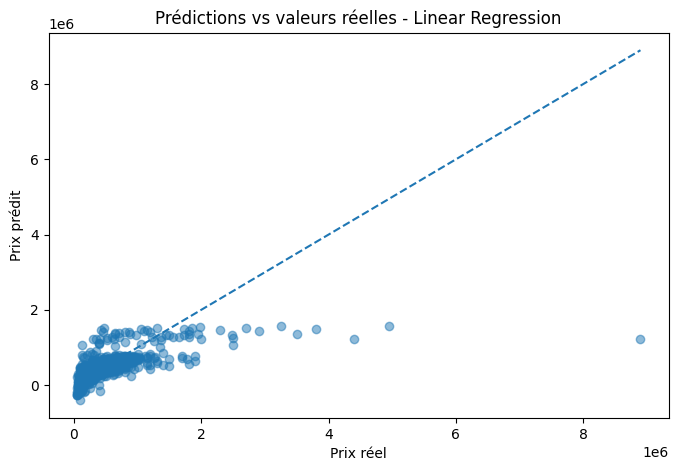

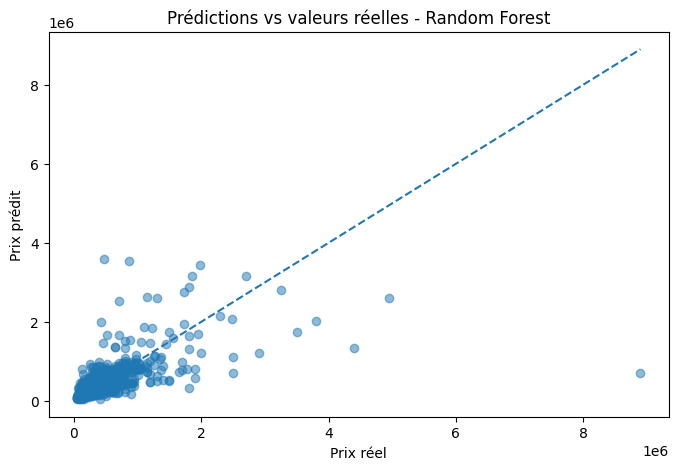

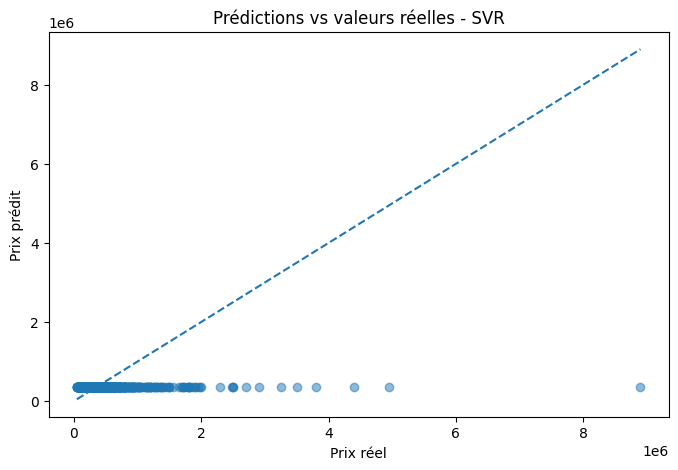

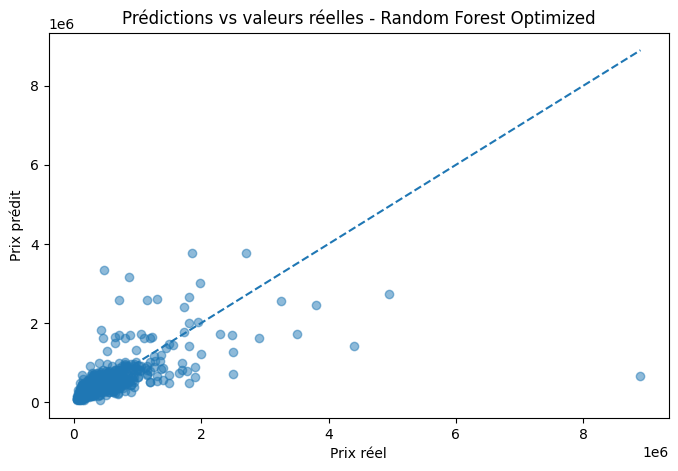

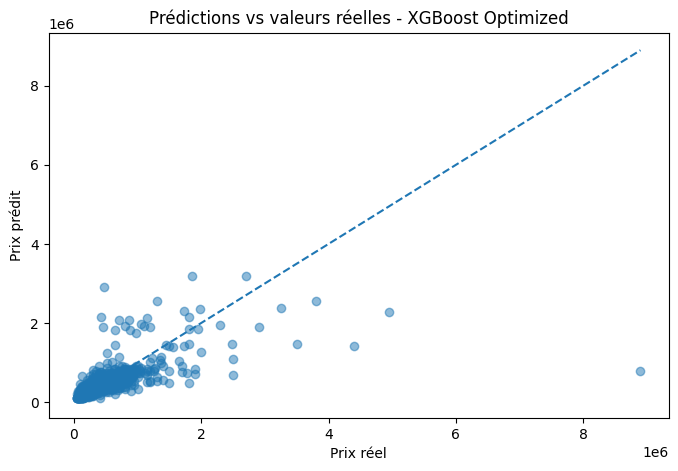

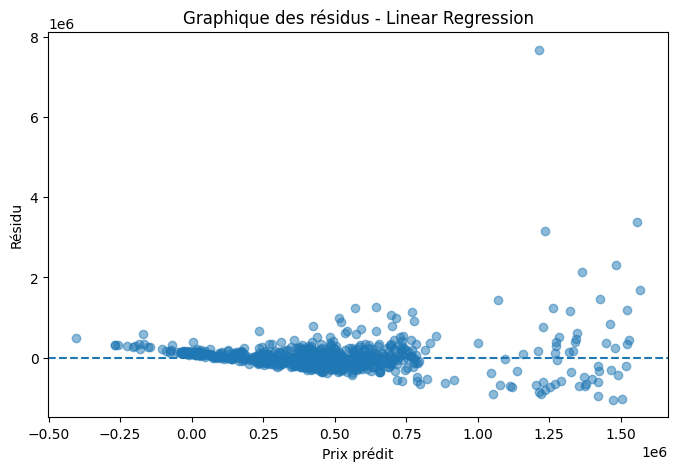

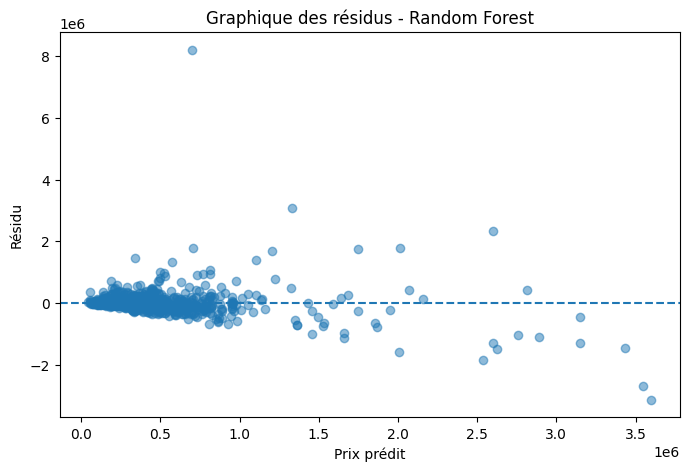

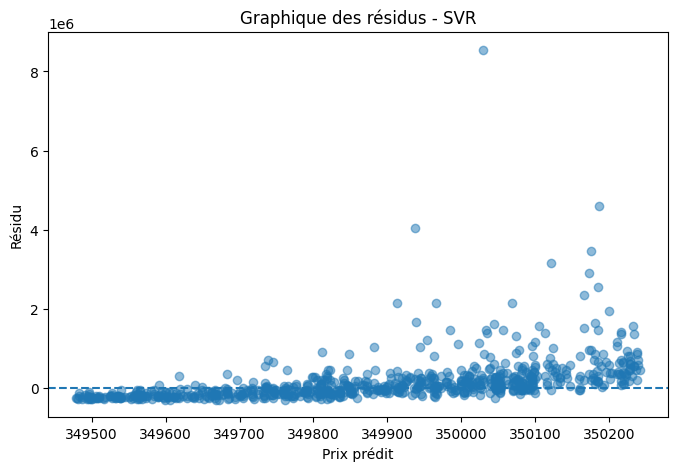

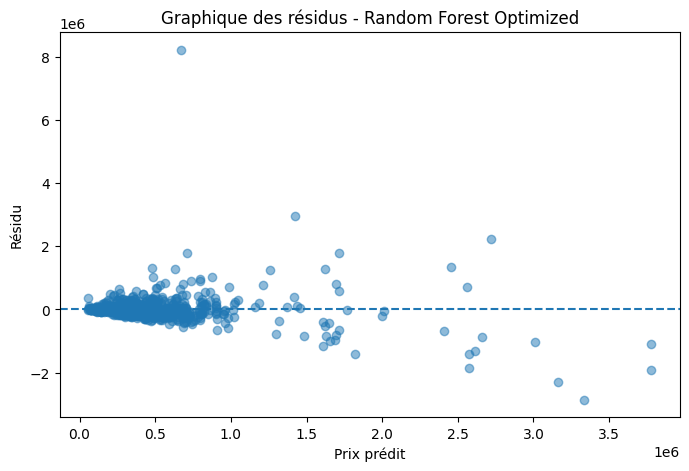

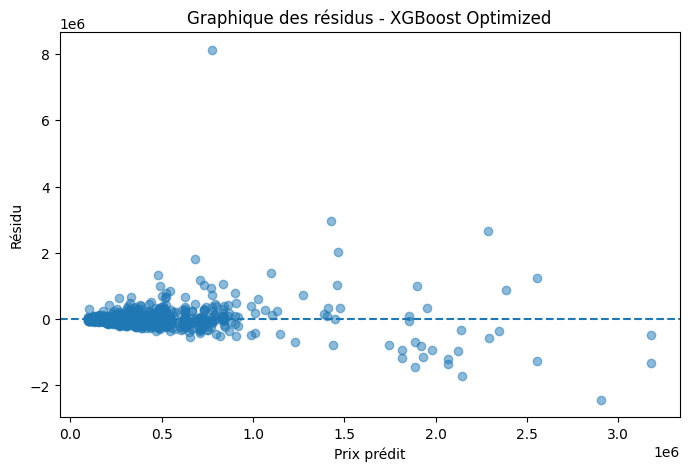



MODÈLES TRIÉS PAR RMSE
                  Model          RMSE           MAE        R2  Error Variance     Error Std
      XGBoost Optimized 457141.380366 194800.104092  0.390993    2.087561e+11 456898.373636
      Linear Regression 457363.620897 219260.148282  0.390401    2.083129e+11 456413.031053
Random Forest Optimized 472281.348897 200982.680568  0.349986    2.229724e+11 472199.513332
          Random Forest 486789.527592 211037.025660  0.309437    2.368123e+11 486633.672628
                    SVR 604850.281781 297760.626622 -0.066147    3.430334e+11 585690.508370


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.svm import SVR

from xgboost import XGBRegressor

from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder

from sklearn.model_selection import train_test_split, GridSearchCV

from sklearn.metrics import (
    mean_squared_error,
    mean_absolute_error,
    r2_score
)


df = pd.read_csv("../data/clean_car_price.csv")

print("Dimensions du dataset :")
print(df.shape)

print("\nColonnes du dataset :")
print(df.columns)


X = df.drop(columns=["selling_price"])

y = df["selling_price"]


X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42
)

print("\nTaille X_train :", X_train.shape)
print("Taille X_test :", X_test.shape)


numeric_features = [
    "year",
    "km_driven"
]

categorical_features = [
    "fuel",
    "seller_type",
    "transmission",
    "owner"
]


numeric_transformer = StandardScaler()


categorical_transformer = OneHotEncoder(
    drop="first",
    handle_unknown="ignore"
)


preprocessor = ColumnTransformer(
    transformers=[
        ("num", numeric_transformer, numeric_features),
        ("cat", categorical_transformer, categorical_features)
    ]
)


linear_pipeline = Pipeline([
    ("preprocessing", preprocessor),
    ("model", LinearRegression())
])


rf_pipeline = Pipeline([
    ("preprocessing", preprocessor),
    ("model", RandomForestRegressor(
        random_state=42
    ))
])


svr_pipeline = Pipeline([
    ("preprocessing", preprocessor),
    ("model", SVR())
])


baseline_models = {
    "Linear Regression": linear_pipeline,
    "Random Forest": rf_pipeline,
    "SVR": svr_pipeline
}


for name, model in baseline_models.items():

    print(f"\nEntraînement de : {name}")

    model.fit(
        X_train,
        y_train
    )


rf_param_grid = {

    "model__n_estimators": [
        100,
        200
    ],

    "model__max_depth": [
        None,
        10,
        20
    ],

    "model__min_samples_split": [
        2,
        5
    ]
}


rf_grid = GridSearchCV(
    estimator=rf_pipeline,
    param_grid=rf_param_grid,
    cv=5,
    scoring="neg_root_mean_squared_error",
    n_jobs=-1
)


print("\nOptimisation de Random Forest...")

rf_grid.fit(
    X_train,
    y_train
)


print("\nMeilleurs paramètres Random Forest :")
print(rf_grid.best_params_)


xgb_pipeline = Pipeline([
    ("preprocessing", preprocessor),
    ("model", XGBRegressor(
        random_state=42
    ))
])


xgb_param_grid = {

    "model__learning_rate": [
        0.01,
        0.05,
        0.1
    ],

    "model__max_depth": [
        3,
        5,
        7
    ],

    "model__subsample": [
        0.8,
        1.0
    ]
}


xgb_grid = GridSearchCV(
    estimator=xgb_pipeline,
    param_grid=xgb_param_grid,
    cv=5,
    scoring="neg_root_mean_squared_error",
    n_jobs=-1
)


print("\nOptimisation de XGBoost...")

xgb_grid.fit(
    X_train,
    y_train
)


print("\nMeilleurs paramètres XGBoost :")
print(xgb_grid.best_params_)


rf_optimized = rf_grid.best_estimator_

xgb_optimized = xgb_grid.best_estimator_


models = {

    "Linear Regression":
        linear_pipeline,

    "Random Forest":
        rf_pipeline,

    "SVR":
        svr_pipeline,

    "Random Forest Optimized":
        rf_optimized,

    "XGBoost Optimized":
        xgb_optimized
}


predictions = {}


for name, model in models.items():

    print(f"\nPrédiction avec : {name}")

    predictions[name] = model.predict(
        X_test
    )


results = []


for name, y_pred in predictions.items():

    mae = mean_absolute_error(
        y_test,
        y_pred
    )

    mse = mean_squared_error(
        y_test,
        y_pred
    )

    rmse = np.sqrt(mse)

    r2 = r2_score(
        y_test,
        y_pred
    )

    residuals = y_test - y_pred

    error_variance = np.var(
        residuals
    )

    error_std = np.std(
        residuals
    )


    results.append({

        "Model": name,

        "RMSE": rmse,

        "MAE": mae,

        "R2": r2,

        "Error Variance":
            error_variance,

        "Error Std":
            error_std
    })


results_df = pd.DataFrame(
    results
)


print("\n")
print("=" * 70)
print("RÉSULTATS FINAUX")
print("=" * 70)

print(
    results_df.to_string(
        index=False
    )
)

for name, y_pred in predictions.items():

    plt.figure(
        figsize=(8, 5)
    )

    plt.scatter(
        y_test,
        y_pred,
        alpha=0.5
    )

    plt.plot(
        [
            y_test.min(),
            y_test.max()
        ],
        [
            y_test.min(),
            y_test.max()
        ],
        linestyle="--"
    )

    plt.xlabel(
        "Prix réel"
    )

    plt.ylabel(
        "Prix prédit"
    )

    plt.title(
        f"Prédictions vs valeurs réelles - {name}"
    )

    plt.show()


for name, y_pred in predictions.items():

    residuals = y_test - y_pred

    plt.figure(
        figsize=(8, 5)
    )

    plt.scatter(
        y_pred,
        residuals,
        alpha=0.5
    )

    plt.axhline(
        y=0,
        linestyle="--"
    )

    plt.xlabel(
        "Prix prédit"
    )

    plt.ylabel(
        "Résidu"
    )

    plt.title(
        f"Graphique des résidus - {name}"
    )

    plt.show()


results_sorted = results_df.sort_values(
    by="RMSE"
)


print("\n")
print("=" * 70)
print("MODÈLES TRIÉS PAR RMSE")
print("=" * 70)

print(
    results_sorted.to_string(
        index=False
    )
)